In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
print(os.getcwd())

results_dir = Path("../../results/angle_sweep")
angles = [30, 50, 70]

refined_paths = {
    angle: results_dir / f"tomo_even_frames+tomo_odd_frames_mw{angle}_avg_refined.rec"
    for angle in angles
}

for angle, path in refined_paths.items():
    print(angle, path.exists(), path)

C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks\subexp03
30 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw30_avg_refined.rec
50 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw50_avg_refined.rec
70 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw70_avg_refined.rec


In [3]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)

refined_avg = {}

for angle, path in refined_paths.items():
    refined_avg[angle] = load_volume(path)

In [4]:
def get_xy_slice(vol, z_idx=None):
    if z_idx is None:
        z_idx = vol.shape[0] // 2
    return vol[z_idx, :, :]


def get_xz_slice(vol, y_idx=None):
    if y_idx is None:
        y_idx = vol.shape[1] // 2
    return vol[:, y_idx, :]


def get_yz_slice(vol, x_idx=None):
    if x_idx is None:
        x_idx = vol.shape[2] // 2
    return vol[:, :, x_idx]

Shared overlay_vmax: 0.28018575191497797
Shared overlay_threshold: 0.04202786278724669


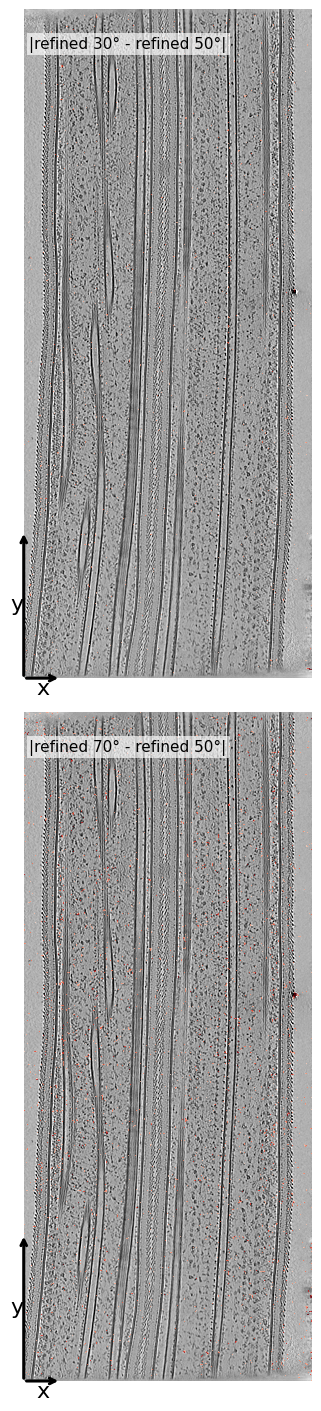

Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_XY_natural_aspect.png
Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_XY_natural_aspect.pdf


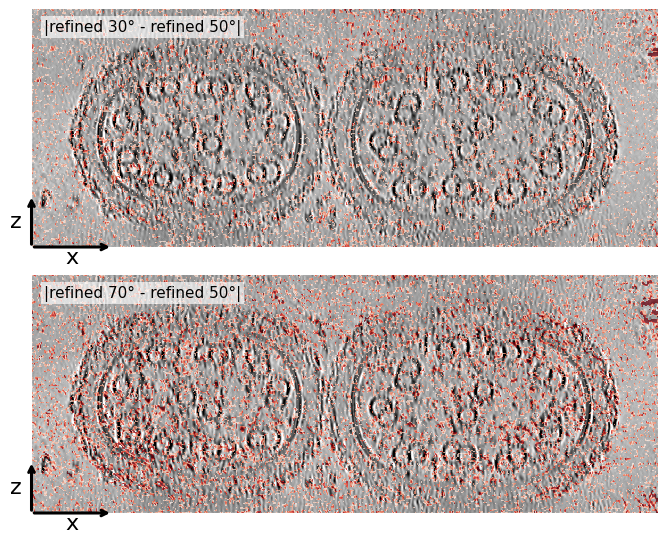

Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_XZ_natural_aspect.png
Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_XZ_natural_aspect.pdf


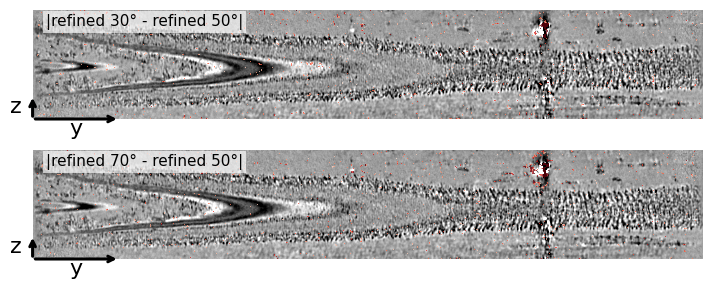

Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_YZ_natural_aspect.png
Saved: ..\..\figures\subexp01\overlay_panels_natural_aspect\subexp01_abs_overlay_YZ_natural_aspect.pdf


In [9]:
baseline_angle = 50
compare_angles = [30, 70]

baseline_vol = refined_avg[baseline_angle]

# slice indices
z_idx = baseline_vol.shape[0] // 2   # XY
y_idx = baseline_vol.shape[1] // 2   # XZ
x_idx = baseline_vol.shape[2] // 2   # YZ

# overwrite if needed
# y_idx = 640

threshold_fraction = 0.15
overlay_alpha = 0.75
overlay_cmap = "Reds"

out_dir = Path("../../figures/subexp01/overlay_panels_natural_aspect")
out_dir.mkdir(parents=True, exist_ok=True)


def robust_limits(img, p_low=1, p_high=99):
    return np.percentile(img[np.isfinite(img)], [p_low, p_high])


def get_plane_slice(vol, plane):
    if plane == "XY":
        return get_xy_slice(vol, z_idx=z_idx)
    elif plane == "XZ":
        return get_xz_slice(vol, y_idx=y_idx)
    elif plane == "YZ":
        return get_yz_slice(vol, x_idx=x_idx)
    else:
        raise ValueError("plane must be XY, XZ, or YZ")


def figsize_from_image(img, target_width=7.0, min_height=1.4, max_height=7.0):
    """
    Choose figure size from image shape.
    Keeps natural image aspect ratio.
    """
    h, w = img.shape
    aspect = h / w
    height = target_width * aspect
    height = np.clip(height, min_height, max_height)
    return (target_width, height)


def add_axis_icon(ax, plane, x0=0, y0=0, dx=0.13, dy=0.22):
    """
    Draw small orientation icon near the bottom-left border,
    with labels placed more at the outer edge like in the paper.
    """
    if plane == "XY":
        h_label, v_label = "x", "y"
    elif plane == "XZ":
        h_label, v_label = "x", "z"
    elif plane == "YZ":
        h_label, v_label = "y", "z"
    else:
        raise ValueError("plane must be XY, XZ, or YZ")

    # arrows
    ax.annotate(
        "", xy=(x0 + dx, y0), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )
    ax.annotate(
        "", xy=(x0, y0 + dy), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )

    # horizontal label: lower, closer to bottom edge
    ax.text(
        x0 + dx / 2, y0 - 0, h_label,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16, color="black"
    )

    # vertical label: further left, more at outer edge
    ax.text(
        x0 - 0.025, y0 + dy / 2, v_label,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16, color="black"
    )


# ------------------------------------------------------------
# Step 1: extract slices only
# ------------------------------------------------------------

planes = ["XY", "XZ", "YZ"]

baseline_slices = {
    plane: get_plane_slice(baseline_vol, plane).astype(np.float32)
    for plane in planes
}

diff_slices = {}

for angle in compare_angles:
    diff_slices[angle] = {}
    for plane in planes:
        cond_slice = get_plane_slice(refined_avg[angle], plane).astype(np.float32)
        diff_slices[angle][plane] = np.abs(cond_slice - baseline_slices[plane])


# ------------------------------------------------------------
# Step 2: shared overlay scale across all panels
# ------------------------------------------------------------

all_overlay_values = np.concatenate([
    diff_slices[angle][plane].ravel()
    for angle in compare_angles
    for plane in planes
])

overlay_vmax = np.percentile(all_overlay_values, 99)
overlay_threshold = threshold_fraction * overlay_vmax

print("Shared overlay_vmax:", overlay_vmax)
print("Shared overlay_threshold:", overlay_threshold)


# ------------------------------------------------------------
# Step 3: save each plane separately, natural aspect ratio
# ------------------------------------------------------------

for plane in planes:

    bg = baseline_slices[plane]

    # Natural aspect figure size
    figsize = figsize_from_image(bg, target_width=7.0)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(figsize[0], 2 * figsize[1]),
        constrained_layout=True
    )

    for row, angle in enumerate(compare_angles):
        ax = axes[row]

        diff = diff_slices[angle][plane]
        bg_vmin, bg_vmax = robust_limits(bg, 1, 99)

        ax.imshow(
            bg,
            cmap="gray",
            origin="lower",
            vmin=bg_vmin,
            vmax=bg_vmax,
            aspect="equal"
        )

        overlay = np.ma.masked_where(diff < overlay_threshold, diff)

        im = ax.imshow(
            overlay,
            cmap=overlay_cmap,
            origin="lower",
            vmin=overlay_threshold,
            vmax=overlay_vmax,
            alpha=overlay_alpha,
            aspect="equal"
        )

        ax.axis("off")
        add_axis_icon(ax, plane)

        ax.text(
            0.02, 0.96,
            f"|refined {angle}° - refined 50°|",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
            color="black",
            bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2)
        )

    save_png = out_dir / f"subexp01_abs_overlay_{plane}_natural_aspect.png"
    save_pdf = out_dir / f"subexp01_abs_overlay_{plane}_natural_aspect.pdf"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    print("Saved:", save_png)
    print("Saved:", save_pdf)

### Subexp02

In [6]:
results_dir_02 = Path("../../experiments/subexp02")
angles_train = [40, 50, 60]

refined_paths_02 = {
    angle: results_dir_02 / f"refine_mw{angle}/tomo_even_frames+tomo_odd_frames_train{angle}_mw50_avg_refined.rec"
    for angle in angles_train
}

for angle, path in refined_paths_02.items():
    print(angle, path.exists(), path)
    

refined_avg_02 = {}

for angle, path in refined_paths_02.items():
    refined_avg_02[angle] = load_volume(path)

40 True ..\..\experiments\subexp02\refine_mw40\tomo_even_frames+tomo_odd_frames_train40_mw50_avg_refined.rec
50 True ..\..\experiments\subexp02\refine_mw50\tomo_even_frames+tomo_odd_frames_train50_mw50_avg_refined.rec
60 True ..\..\experiments\subexp02\refine_mw60\tomo_even_frames+tomo_odd_frames_train60_mw50_avg_refined.rec


Shared overlay_vmax: 0.27326932638883583
Shared overlay_threshold: 0.040990398958325375


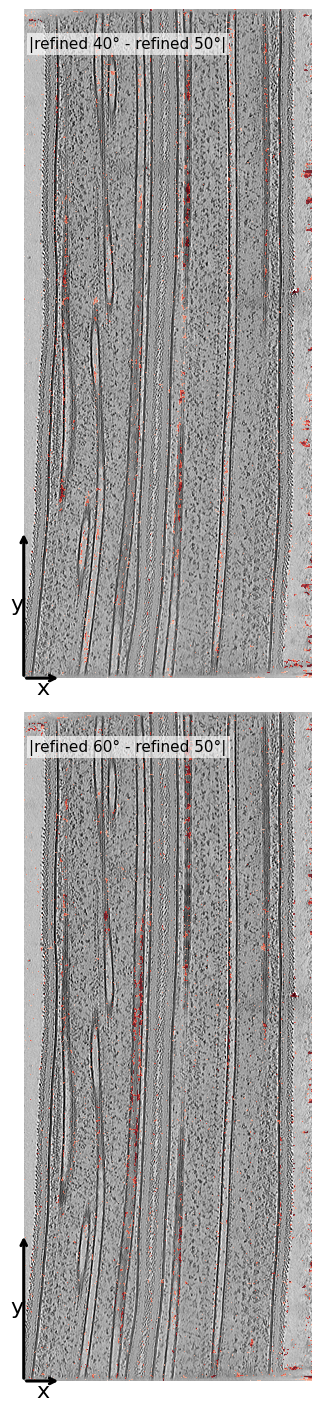

Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_XY_natural_aspect.png
Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_XY_natural_aspect.pdf


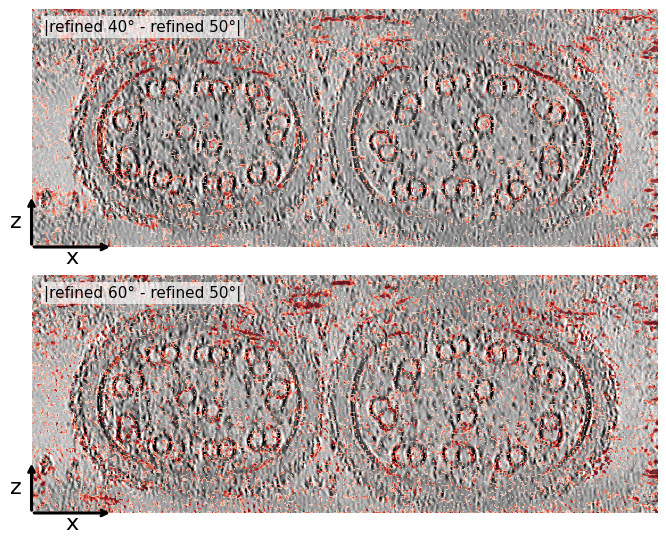

Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_XZ_natural_aspect.png
Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_XZ_natural_aspect.pdf


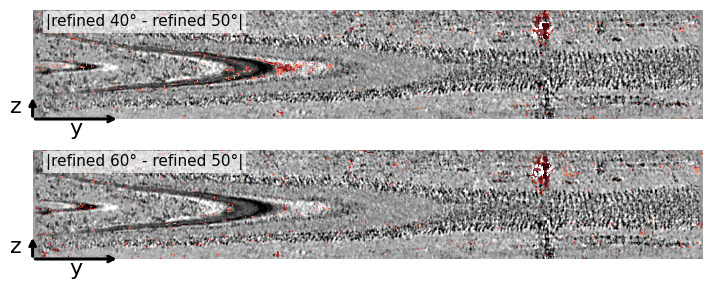

Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_YZ_natural_aspect.png
Saved: ..\..\figures\subexp02\overlay_panels_natural_aspect\subexp02_abs_overlay_YZ_natural_aspect.pdf


In [10]:
baseline_angle = 50
compare_angles = [40, 60]

baseline_vol = refined_avg_02[baseline_angle]

# slice indices
z_idx = baseline_vol.shape[0] // 2   # XY
y_idx = baseline_vol.shape[1] // 2   # XZ
x_idx = baseline_vol.shape[2] // 2   # YZ

# overwrite if needed
# y_idx = 640

threshold_fraction = 0.15
overlay_alpha = 0.75
overlay_cmap = "Reds"

out_dir = Path("../../figures/subexp02/overlay_panels_natural_aspect")
out_dir.mkdir(parents=True, exist_ok=True)


def robust_limits(img, p_low=1, p_high=99):
    return np.percentile(img[np.isfinite(img)], [p_low, p_high])


def get_plane_slice(vol, plane):
    if plane == "XY":
        return get_xy_slice(vol, z_idx=z_idx)
    elif plane == "XZ":
        return get_xz_slice(vol, y_idx=y_idx)
    elif plane == "YZ":
        return get_yz_slice(vol, x_idx=x_idx)
    else:
        raise ValueError("plane must be XY, XZ, or YZ")


def figsize_from_image(img, target_width=7.0, min_height=1.4, max_height=7.0):
    """
    Choose figure size from image shape.
    Keeps natural image aspect ratio.
    """
    h, w = img.shape
    aspect = h / w
    height = target_width * aspect
    height = np.clip(height, min_height, max_height)
    return (target_width, height)


def add_axis_icon(ax, plane, x0=0, y0=0, dx=0.13, dy=0.22):
    """
    Draw small orientation icon near the bottom-left border,
    with labels placed more at the outer edge like in the paper.
    """
    if plane == "XY":
        h_label, v_label = "x", "y"
    elif plane == "XZ":
        h_label, v_label = "x", "z"
    elif plane == "YZ":
        h_label, v_label = "y", "z"
    else:
        raise ValueError("plane must be XY, XZ, or YZ")

    # arrows
    ax.annotate(
        "", xy=(x0 + dx, y0), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )
    ax.annotate(
        "", xy=(x0, y0 + dy), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="black")
    )

    # horizontal label: lower, closer to bottom edge
    ax.text(
        x0 + dx / 2, y0 - 0, h_label,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16, color="black"
    )

    # vertical label: further left, more at outer edge
    ax.text(
        x0 - 0.025, y0 + dy / 2, v_label,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16, color="black"
    )


# ------------------------------------------------------------
# Step 1: extract slices only
# ------------------------------------------------------------

planes = ["XY", "XZ", "YZ"]

baseline_slices = {
    plane: get_plane_slice(baseline_vol, plane).astype(np.float32)
    for plane in planes
}

diff_slices = {}

for angle in compare_angles:
    diff_slices[angle] = {}
    for plane in planes:
        cond_slice = get_plane_slice(refined_avg_02[angle], plane).astype(np.float32)
        diff_slices[angle][plane] = np.abs(cond_slice - baseline_slices[plane])


# ------------------------------------------------------------
# Step 2: shared overlay scale across all panels
# ------------------------------------------------------------

all_overlay_values = np.concatenate([
    diff_slices[angle][plane].ravel()
    for angle in compare_angles
    for plane in planes
])

overlay_vmax = np.percentile(all_overlay_values, 99)
overlay_threshold = threshold_fraction * overlay_vmax

print("Shared overlay_vmax:", overlay_vmax)
print("Shared overlay_threshold:", overlay_threshold)


# ------------------------------------------------------------
# Step 3: save each plane separately, natural aspect ratio
# ------------------------------------------------------------

for plane in planes:

    bg = baseline_slices[plane]

    # Natural aspect figure size
    figsize = figsize_from_image(bg, target_width=7.0)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(figsize[0], 2 * figsize[1]),
        constrained_layout=True
    )

    for row, angle in enumerate(compare_angles):
        ax = axes[row]

        diff = diff_slices[angle][plane]
        bg_vmin, bg_vmax = robust_limits(bg, 1, 99)

        ax.imshow(
            bg,
            cmap="gray",
            origin="lower",
            vmin=bg_vmin,
            vmax=bg_vmax,
            aspect="equal"
        )

        overlay = np.ma.masked_where(diff < overlay_threshold, diff)

        im = ax.imshow(
            overlay,
            cmap=overlay_cmap,
            origin="lower",
            vmin=overlay_threshold,
            vmax=overlay_vmax,
            alpha=overlay_alpha,
            aspect="equal"
        )

        ax.axis("off")
        add_axis_icon(ax, plane)

        ax.text(
            0.02, 0.96,
            f"|refined {angle}° - refined 50°|",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
            color="black",
            bbox=dict(facecolor="white", alpha=0.65, edgecolor="none", pad=2)
        )

    save_png = out_dir / f"subexp02_abs_overlay_{plane}_natural_aspect.png"
    save_pdf = out_dir / f"subexp02_abs_overlay_{plane}_natural_aspect.pdf"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    print("Saved:", save_png)
    print("Saved:", save_pdf)